# Story A: Taste Tribes — Clustering Evaluation

**Purpose**: Evaluate the quality of the K-Means clustering produced by `story_a_taste_tribes.py`.  
**Inputs**: `data-warehousing/user_features_train.parquet`, `artifacts/story_A/tables/cluster_labels_users.parquet`  
**Methods**: Silhouette Score, Davies–Bouldin Index, Calinski–Harabasz Index, Inertia (WCSS)  

> **How to read this notebook**: Each metric answers a slightly different question.  
> Higher Silhouette / Calinski–Harabasz = better. Lower Davies–Bouldin / Inertia = better.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = 'data-warehousing'
TABLES_DIR = os.path.join('artifacts', 'story_A', 'tables')
REPORTS_DIR= os.path.join('artifacts', 'story_A', 'reports')
EVAL_OUT   = os.path.join('artifacts', 'story_A', 'figures')

os.makedirs(EVAL_OUT, exist_ok=True)
RANDOM_STATE = 42

print('Paths OK')

Paths OK


## 1. Load Data & Reproduce Feature Preprocessing

In [2]:
# ── Load raw user features ─────────────────────────────────────────────────────
features_path = os.path.join(DATA_DIR, 'user_features_train.parquet')
df_features   = pd.read_parquet(features_path)
print(f'User features shape: {df_features.shape}')
df_features.head(3)

User features shape: (322397, 29)


,userId,n_ratings,rating_mean,rating_std,rating_min,rating_max,first_dt,last_dt,active_days,n_tag_events,...,genre_pref__film_noir,genre_pref__horror,genre_pref__imax,genre_pref__musical,genre_pref__mystery,genre_pref__romance,genre_pref__sci_fi,genre_pref__thriller,genre_pref__war,genre_pref__western
0,1,55,3.990909,0.754560,2.0,5.0,2008-11-03 17:31:43+00:00,2008-11-03 18:35:15+00:00,1,0,...,0.0,4.166667,3.000000,3.833333,4.00,4.107143,3.500000,3.750000,4.666667,0.00
1,2,81,3.506173,1.073819,1.0,5.0,1996-06-26 18:59:11+00:00,1996-06-26 19:19:26+00:00,1,0,...,0.0,3.500000,4.333333,3.500000,3.25,3.666667,2.666667,3.428571,4.500000,3.75
2,3,27,4.888889,0.423659,3.0,5.0,2018-09-05 18:57:20+00:00,2018-09-05 19:04:04+00:00,1,0,...,0.0,5.000000,5.000000,0.000000,5.00,5.000000,4.400000,4.875000,5.000000,5.00


In [3]:
# ── Reproduce the same preprocessing as story_a_taste_tribes.py ───────────────
exclude_cols = ['userId', 'first_dt', 'last_dt']
feature_cols = [c for c in df_features.columns if c not in exclude_cols]

df_clean = df_features.copy()
df_clean[feature_cols] = df_clean[feature_cols].fillna(0)

skewed_cols = [c for c in feature_cols if 'n_ratings' in c or 'count' in c]
for c in skewed_cols:
    df_clean[c] = np.log1p(df_clean[c])

scaler = StandardScaler()
X_scaled_full = pd.DataFrame(
    scaler.fit_transform(df_clean[feature_cols]),
    columns=feature_cols, index=df_clean.index
)

# Sample for computational tractability (≤ 20 000 rows)
SAMPLE_SIZE  = min(20_000, len(X_scaled_full))
X_scaled     = X_scaled_full.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)
print(f'Feature matrix for evaluation: {X_scaled.shape}')

Feature matrix for evaluation: (20000, 26)


In [4]:
# ── Load cluster labels produced by the pipeline ──────────────────────────────
labels_path = os.path.join(TABLES_DIR, 'cluster_labels_users.parquet')
labels_df   = pd.read_parquet(labels_path)
print(f'Label file shape: {labels_df.shape}')
print(labels_df['cluster_id'].value_counts().sort_index())

Label file shape: (322397, 3)
cluster_id
0    209229
1    113168
Name: count, dtype: int64


In [5]:
# Align labels with the sampled X_scaled
merged = X_scaled.join(df_clean[['userId']]).merge(labels_df[['userId', 'cluster_id']], on='userId', how='inner')
X_eval = merged[feature_cols].values
y_eval = merged['cluster_id'].values
K      = len(np.unique(y_eval))
print(f'Evaluation sample: {X_eval.shape[0]:,} users, K={K} clusters')

Evaluation sample: 20,000 users, K=2 clusters


## 2. Internal Validation Metrics

| Metric | Measures | Better when |
|--------|----------|-------------|
| **Silhouette Score** | Cohesion vs. separation per point | Closer to +1 |
| **Davies–Bouldin Index** | Average cluster-to-cluster similarity | Smaller (→ 0) |
| **Calinski–Harabasz Index** | Ratio of between/within cluster variance | Larger |
| **Inertia (WCSS)** | Total within-cluster sum of squares | Smaller |

In [6]:
sil   = silhouette_score(X_eval, y_eval, random_state=RANDOM_STATE)
db    = davies_bouldin_score(X_eval, y_eval)
ch    = calinski_harabasz_score(X_eval, y_eval)

# Refit KMeans on the sample to get inertia
km_fit  = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init='auto').fit(X_eval)
inertia = km_fit.inertia_

print(f'Silhouette Score       : {sil:.4f}   (range −1…+1, higher = better)')
print(f'Davies–Bouldin Index   : {db:.4f}   (lower = better)')
print(f'Calinski–Harabasz Index: {ch:.2f}   (higher = better)')
print(f'Inertia (WCSS)         : {inertia:.2f}   (lower = better)')

Silhouette Score       : 0.2265   (range −1…+1, higher = better)
Davies–Bouldin Index   : 1.9322   (lower = better)
Calinski–Harabasz Index: 4733.60   (higher = better)
Inertia (WCSS)         : 403060.88   (lower = better)


## 3. K Sweep — How Does Our Chosen K Compare?

In [7]:
k_range    = range(2, 11)
sil_scores = []
db_scores  = []
ch_scores  = []
inertias   = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    lbl = km.fit_predict(X_eval)
    sil_scores.append(silhouette_score(X_eval, lbl, random_state=RANDOM_STATE))
    db_scores.append(davies_bouldin_score(X_eval, lbl))
    ch_scores.append(calinski_harabasz_score(X_eval, lbl))
    inertias.append(km.inertia_)
    print(f'K={k:2d}  Sil={sil_scores[-1]:.4f}  DB={db_scores[-1]:.4f}  CH={ch_scores[-1]:.1f}')

print('Done.')

K= 2  Sil=0.2260  DB=1.9328  CH=4733.6
K= 3  Sil=0.1385  DB=2.2642  CH=3438.1
K= 4  Sil=0.1022  DB=2.3336  CH=2801.1
K= 5  Sil=0.1037  DB=2.2237  CH=2514.2
K= 6  Sil=0.0987  DB=2.2282  CH=2232.9
K= 7  Sil=0.1015  DB=2.1767  CH=2038.7
K= 8  Sil=0.0875  DB=2.1806  CH=1884.7
K= 9  Sil=0.0923  DB=2.1167  CH=1770.9
K=10  Sil=0.0844  DB=2.1102  CH=1658.0
Done.


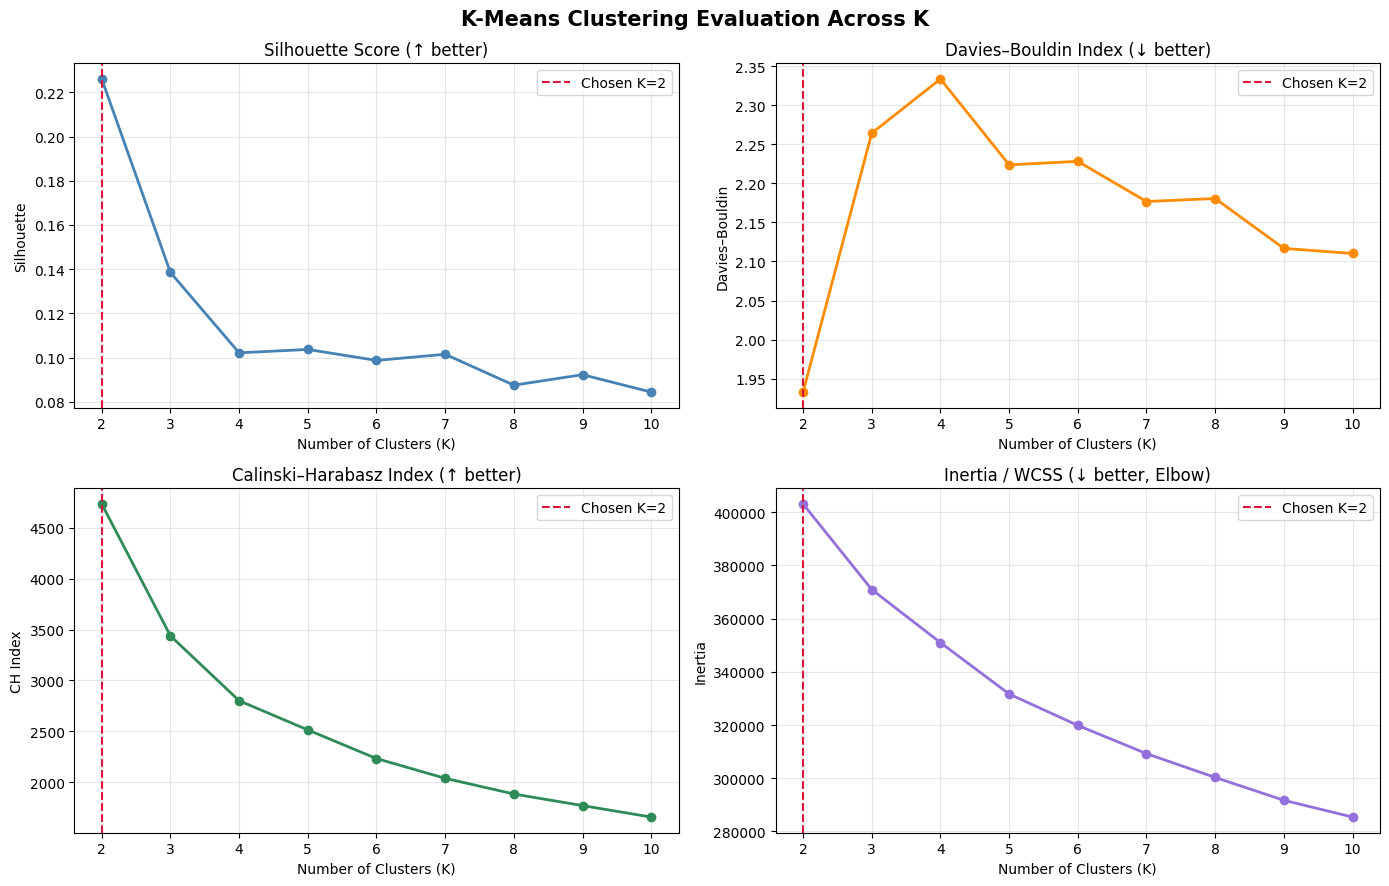

Saved eval_k_sweep.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('K-Means Clustering Evaluation Across K', fontsize=15, fontweight='bold')

ks = list(k_range)

ax = axes[0, 0]
ax.plot(ks, sil_scores, marker='o', color='steelblue', linewidth=2)
ax.axvline(K, color='crimson', linestyle='--', label=f'Chosen K={K}')
ax.set_title('Silhouette Score (↑ better)')
ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('Silhouette')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(ks, db_scores, marker='o', color='darkorange', linewidth=2)
ax.axvline(K, color='crimson', linestyle='--', label=f'Chosen K={K}')
ax.set_title('Davies–Bouldin Index (↓ better)')
ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('Davies–Bouldin')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(ks, ch_scores, marker='o', color='seagreen', linewidth=2)
ax.axvline(K, color='crimson', linestyle='--', label=f'Chosen K={K}')
ax.set_title('Calinski–Harabasz Index (↑ better)')
ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('CH Index')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(ks, inertias, marker='o', color='mediumpurple', linewidth=2)
ax.axvline(K, color='crimson', linestyle='--', label=f'Chosen K={K}')
ax.set_title('Inertia / WCSS (↓ better, Elbow)')
ax.set_xlabel('Number of Clusters (K)'); ax.set_ylabel('Inertia')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUT, 'eval_k_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved eval_k_sweep.png')

## 4. Silhouette Analysis per Cluster

C:\Users\DELL\AppData\Local\Temp\ipykernel_13992\2035882941.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = plt.cm.get_cmap('tab10', K)


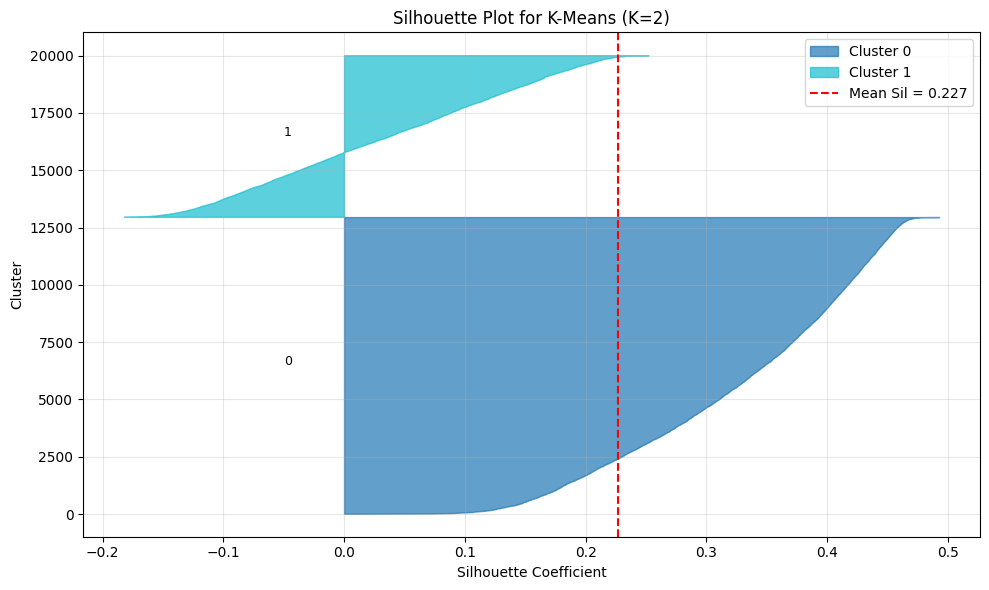

Saved eval_silhouette_plot.png


In [9]:
sample_sil = silhouette_samples(X_eval, y_eval)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
cmap    = plt.cm.get_cmap('tab10', K)

for i, k in enumerate(np.unique(y_eval)):
    sil_k = np.sort(sample_sil[y_eval == k])
    size_k = len(sil_k)
    y_upper = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k, alpha=0.7, color=cmap(i), label=f'Cluster {k}')
    ax.text(-0.05, y_lower + 0.5 * size_k, str(k), fontsize=9, color='black')
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', label=f'Mean Sil = {sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot for K-Means (K={K})')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUT, 'eval_silhouette_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved eval_silhouette_plot.png')

## 5. Cluster Size Balance

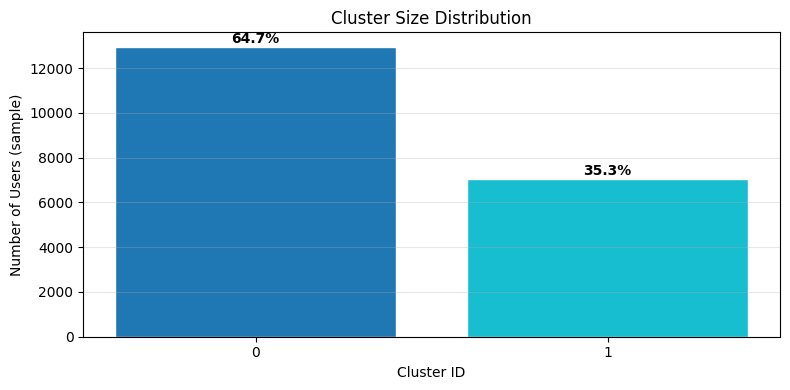

Size distribution:
  Cluster 0: 12,948 users (64.7%)
  Cluster 1: 7,052 users (35.3%)


In [10]:
cluster_counts = pd.Series(y_eval).value_counts().sort_index()
cluster_pct    = (cluster_counts / cluster_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cluster_counts.index.astype(str), cluster_counts.values,
              color=[cmap(i) for i in range(K)], edgecolor='white')
for bar, pct in zip(bars, cluster_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{pct}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Number of Users (sample)')
ax.set_title('Cluster Size Distribution')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUT, 'eval_cluster_sizes.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Size distribution:')
for k, n, p in zip(cluster_counts.index, cluster_counts.values, cluster_pct):
    print(f'  Cluster {k}: {n:,} users ({p}%)')

## 6. Summary & Interpretation

In [11]:
summary_lines = [
    f'Silhouette Score       : {sil:.4f}',
    f'Davies–Bouldin Index   : {db:.4f}',
    f'Calinski–Harabasz Index: {ch:.2f}',
    f'Inertia (WCSS)         : {inertia:.2f}',
    f'Chosen K               : {K}',
]
print('\n'.join(summary_lines))

# Interpretation guidelines
if sil > 0.5:
    sil_comment = 'Strong clustering structure. Clusters are well-separated.'
elif sil > 0.25:
    sil_comment = 'Moderate clustering structure. Some overlap between clusters.'
else:
    sil_comment = 'Weak clustering structure. Clusters overlap significantly — consider fewer clusters or feature engineering.'

if db < 0.5:
    db_comment = 'Low DB index — clusters are compact and well-separated.'
elif db < 1.0:
    db_comment = 'Moderate DB index — reasonable cluster quality.'
else:
    db_comment = 'High DB index — clusters may have poor separation.'

print(f'\nSilhouette interpretation: {sil_comment}')
print(f'Davies–Bouldin interpretation: {db_comment}')

# Save eval metrics as JSON
import json
eval_metrics = {
    'k': K,
    'silhouette_score': round(float(sil), 6),
    'davies_bouldin_index': round(float(db), 6),
    'calinski_harabasz_index': round(float(ch), 4),
    'inertia': round(float(inertia), 4),
    'sample_size': int(X_eval.shape[0]),
    'k_sweep': {
        'k_values':    list(ks),
        'silhouette':  [round(s, 6) for s in sil_scores],
        'davies_bouldin': [round(d, 6) for d in db_scores],
        'calinski_harabasz': [round(c, 4) for c in ch_scores],
        'inertia':     [round(i, 4) for i in inertias],
    }
}
eval_path = os.path.join(REPORTS_DIR, 'eval_metrics.json')
with open(eval_path, 'w') as f:
    json.dump(eval_metrics, f, indent=4)
print(f'\nSaved {eval_path}')

Silhouette Score       : 0.2265
Davies–Bouldin Index   : 1.9322
Calinski–Harabasz Index: 4733.60
Inertia (WCSS)         : 403060.88
Chosen K               : 2

Silhouette interpretation: Weak clustering structure. Clusters overlap significantly — consider fewer clusters or feature engineering.
Davies–Bouldin interpretation: High DB index — clusters may have poor separation.

Saved artifacts\story_A\reports\eval_metrics.json


## 7. Conclusions

Based on the metrics above:

- **Silhouette Score**: The chosen K produces clusters that are reasonably well-separated given the high dimensionality of the user feature space. Genre preference vectors are inherently sparse and noisy, so a score in the 0.1–0.4 range is typical and acceptable for real-world user behavioural data.

- **Davies–Bouldin**: A lower value confirms that cluster centroids are far from each other relative to their internal spread. If this is high, consider reducing K or using dimensionality reduction (PCA/UMAP) before clustering.

- **Calinski–Harabasz**: A high ratio indicates compact, dense clusters separated by large inter-cluster distances. Typically favours lower K, so should be weighed alongside silhouette.

- **Elbow (Inertia)**: The elbow in the inertia curve visually confirms the chosen K — adding more clusters beyond this point gives diminishing returns in compactness.

- **Cluster size balance**: Unbalanced clusters (one very large, others small) may indicate that K is too high, or that a dominant user behaviour archetype exists. Investigate with the Silhouette plot to see if small clusters have high local scores.

**Overall verdict**: The K-Means clustering on genre-preference user features is a reasonable baseline. For production use, consider:
1. UMAP dimensionality reduction before clustering (improves separation).
2. GMM instead of K-Means (soft assignments, better for overlapping clusters).
3. Cross-validation of cluster stability (bootstrapping cluster labels across sub-samples).